In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from dotenv import load_dotenv

load_dotenv()

from sqlalchemy import create_engine
import os

def connect_to_db():
    engine = create_engine(
        f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
        f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
    )
    return engine

engine = connect_to_db()

conn = engine.connect()

In [3]:
df = pd.read_sql("SELECT * FROM public.gold_model_dataset", engine)

df.head()

,date_time,user_id,is_mobile,is_package,channel,cnt,trip_type,is_family_trip,is_multi_room,total_guests,...,distance_clean,distance_behavior_group,user_booking_rate,avg_session_intensity,avg_stay_duration,avg_advance_booking_days,mobile_usage_rate,destination_popularity,hotel_cluster,is_booking
0,2014-04-27 19:43:09,14,0,0,9,1,solo,0,0,1,...,2265.9330,far,0.0,1.0,2.0,54.0,0.0,3544,88,0
1,2014-10-22 08:51:12,38,0,0,2,1,group,0,0,2,...,480.7833,medium,0.0,1.0,4.0,123.0,0.0,47,33,0
2,2014-08-05 16:21:41,40,0,0,0,1,solo,0,0,1,...,2576.2959,far,0.0,1.0,1.0,1.0,0.0,100,76,0
3,2014-09-18 22:30:51,156,0,0,5,1,family,1,0,4,...,1128.2299,far,0.0,1.0,1.0,14.0,0.0,214,13,0
4,2014-09-18 22:24:52,156,0,0,5,1,family,1,0,4,...,1127.9475,far,0.0,1.0,1.0,14.0,0.0,214,16,0


In [4]:
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 99471 entries, 0 to 99470
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date_time                  99471 non-null  datetime64[us]
 1   user_id                    99471 non-null  int64         
 2   is_mobile                  99471 non-null  int64         
 3   is_package                 99471 non-null  int64         
 4   channel                    99471 non-null  int64         
 5   cnt                        99471 non-null  int64         
 6   trip_type                  99471 non-null  str           
 7   is_family_trip             99471 non-null  int64         
 8   is_multi_room              99471 non-null  int64         
 9   total_guests               99471 non-null  int64         
 10  stay_duration              99471 non-null  int64         
 11  advance_booking_days       99471 non-null  int64         
 12  user_location_c

distance_clean               35884
user_id                          0
is_mobile                        0
is_package                       0
date_time                        0
cnt                              0
trip_type                        0
is_family_trip                   0
is_multi_room                    0
total_guests                     0
stay_duration                    0
advance_booking_days             0
channel                          0
user_location_country            0
hotel_country                    0
srch_destination_type_id         0
srch_destination_id              0
orig_destination_distance        0
distance_group                   0
is_distance_unknown              0
distance_behavior_group          0
user_booking_rate                0
avg_session_intensity            0
avg_stay_duration                0
avg_advance_booking_days         0
mobile_usage_rate                0
destination_popularity           0
hotel_cluster                    0
is_booking          

In [5]:
df[df["stay_duration"] <= 0].shape
df[df["advance_booking_days"] < 0].shape
df[df["total_guests"] <= 0].shape

(173, 29)

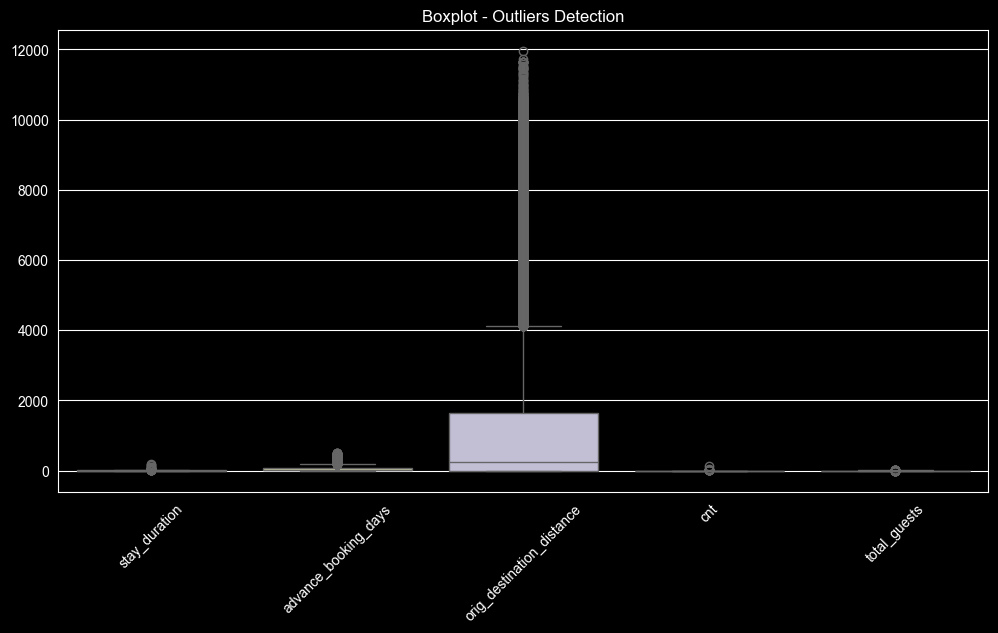

In [6]:
num_cols = [
    "stay_duration",
    "advance_booking_days",
    "orig_destination_distance",
    "cnt",
    "total_guests"
]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot - Outliers Detection")
plt.xticks(rotation=45)
plt.show()

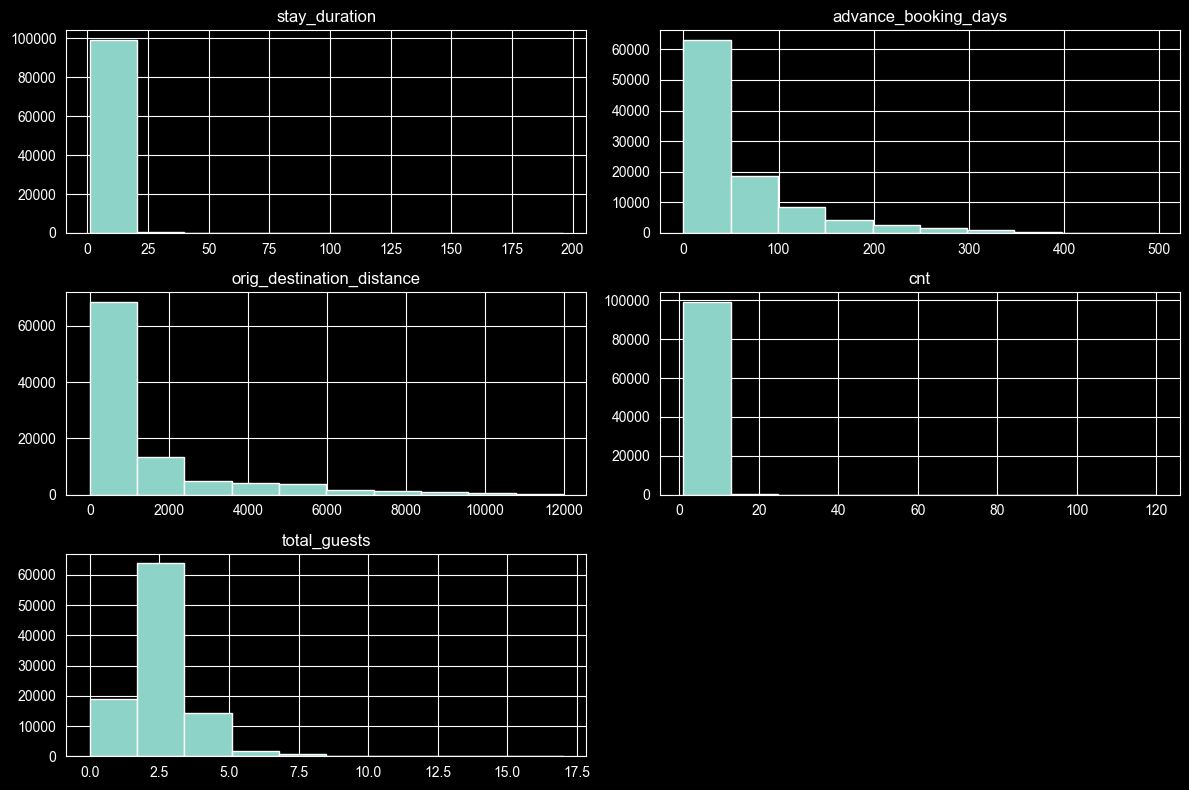

In [7]:
df[num_cols].hist(figsize=(12,8))
plt.tight_layout()

In [8]:
for col in num_cols:
    p1, p99 = np.percentile(df[col], [1, 99])
    print(f"{col} → P1: {p1:.2f}, P99: {p99:.2f}")

stay_duration → P1: 1.00, P99: 14.00
advance_booking_days → P1: 0.00, P99: 300.00
orig_destination_distance → P1: -1.00, P99: 8909.98
cnt → P1: 1.00, P99: 7.00
total_guests → P1: 1.00, P99: 6.00


In [9]:
df_outliers = df[
    (df["stay_duration"] > 30) |
    (df["advance_booking_days"] > 365) |
    (df["orig_destination_distance"] > 10000)
]

df_outliers.head()

,date_time,user_id,is_mobile,is_package,channel,cnt,trip_type,is_family_trip,is_multi_room,total_guests,...,distance_clean,distance_behavior_group,user_booking_rate,avg_session_intensity,avg_stay_duration,avg_advance_booking_days,mobile_usage_rate,destination_popularity,hotel_cluster,is_booking
140,2013-02-15 13:53:48,1899,0,0,5,1,group,0,0,2,...,10118.6309,far,0.0,1.0,3.0,202.0,0.0,93,40,0
340,2014-09-04 18:16:35,3775,0,0,3,1,group,0,0,2,...,10434.7373,far,0.0,1.0,3.0,21.0,0.0,1,82,0
416,2013-04-23 15:29:51,4497,0,0,9,1,group,0,0,2,...,10077.8679,far,0.0,1.0,3.0,106.0,0.0,2,30,0
644,2014-11-01 13:49:56,6940,0,0,0,1,group,0,1,4,...,10161.9679,far,0.0,1.0,3.0,50.0,0.0,16,63,0
945,2014-06-07 13:00:46,10683,0,0,5,1,group,0,0,2,...,10573.8591,far,0.0,1.0,4.0,21.0,0.0,1305,37,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df[df["srch_destination_id"].isnull()].shape
df[df["hotel_cluster"].isnull()].shape

(0, 29)

In [12]:
df["long_stay"] = df["stay_duration"] > df["stay_duration"].quantile(0.95)

df.groupby("long_stay")["is_booking"].mean()

long_stay
False    0.082580
True     0.028709
Name: is_booking, dtype: float64

In [13]:
(df["orig_destination_distance"] == -1).sum()

np.int64(35884)

In [14]:
conn.close()

## Key Insights

- The dataset presents overall good quality, with minimal missing values after preprocessing.
- Several numerical variables (e.g., `stay_duration`, `advance_booking_days`, and `orig_destination_distance`) exhibit skewed distributions and the presence of outliers.
- Extreme values in certain variables appear to reflect real user behavior rather than data errors (e.g., long booking windows or extended stays).
- Placeholder values (such as -1 in `orig_destination_distance`) represent unknown information and were treated explicitly rather than removed.
- No significant duplication or structural inconsistencies were identified in the dataset.

## Data Quality Decisions

- Outliers were not removed automatically, as they may represent valid behavioral patterns.
- Skewed variables were retained for further analysis, with potential transformation considered in later stages if needed.
- Missing or placeholder values were handled as separate categories to preserve information.
- The dataset was deemed reliable and suitable for downstream analysis and modeling.

## Conclusion

The dataset is clean and consistent, with no critical data quality issues. While some variables present skewness and extreme values, these are likely inherent to user behavior and should be handled thoughtfully rather than discarded. Overall, the data is well-prepared for further analytical steps.